This is the scratchpad to work out the code before rewriting it as a block script in volatility_renewable_share. I find it easier to debug and create in a notebook.

In [103]:
from pathlib import Path
import sys
sys.path.append("..") #notebook workaround for relative imports - not needed in the final script file
import pandas as pd
import statsmodels.formula.api as smf
from src.pipeline_utils import get_engine

In [106]:
engine = get_engine()
with engine.begin() as conn:
    df_generation = pd.read_sql("SELECT * FROM generation", conn)
df_generation["timestamp"] = pd.to_datetime(df_generation["timestamp"])

In [107]:
df_generation.head()

,zone,timestamp,production_type,value_mw
0,DE_LU,2026-09-14 22:00:00+00:00,Biomass,3847.93709
1,DE_LU,2026-09-14 22:15:00+00:00,Biomass,3832.25409
2,DE_LU,2026-09-14 22:30:00+00:00,Biomass,3821.68579
3,DE_LU,2026-09-14 22:45:00+00:00,Biomass,3812.94209
4,DE_LU,2026-09-14 23:00:00+00:00,Biomass,3798.16749


The where here is for future proofing. The one below. Build into the function for the script.

In [108]:
with engine.begin() as conn:
    df_price = pd.read_sql("SELECT * FROM prices WHERE zone IN ('DE_LU', 'SE_4')", conn)
df_price["timestamp"] = pd.to_datetime(df_price["timestamp"])

In [109]:
df_price.head()

,zone,timestamp,price_eur_mwh
0,DE_LU,2025-12-01 23:00:00+00:00,74.08
1,DE_LU,2025-12-01 23:15:00+00:00,69.92
2,DE_LU,2025-12-01 23:30:00+00:00,63.16
3,DE_LU,2025-12-01 23:45:00+00:00,55.95
4,DE_LU,2025-12-02 00:00:00+00:00,65.41


The clip here in the code below is to kill hydro water storage when negative which isnt strictly generation.

In [110]:
generation_wide_df = df_generation.pivot(index=['zone','timestamp'], columns='production_type', values='value_mw').clip(lower=0)

In [111]:
generation_wide_df.head()

production_type                      Biomass  Fossil Brown coal/Lignite  \
zone  timestamp                                                           
DE_LU 2025-12-01 23:00:00+00:00  3747.499144                 6912.68041   
      2025-12-01 23:15:00+00:00  3746.302984                 6923.59182   
      2025-12-01 23:30:00+00:00  3757.497088                 6915.54587   
      2025-12-01 23:45:00+00:00  3764.604516                 6854.23653   
      2025-12-02 00:00:00+00:00  3755.147836                 6596.57927   

production_type                  Fossil Coal-derived gas  Fossil Gas  \
zone  timestamp                                                        
DE_LU 2025-12-01 23:00:00+00:00                492.45667  6304.37520   
      2025-12-01 23:15:00+00:00                574.95667  6106.24293   
      2025-12-01 23:30:00+00:00                580.10334  6013.96636   
      2025-12-01 23:45:00+00:00                591.70667  5972.12206   
      2025-12-02 00:00:00+00:00                605.11334  6006.44944   

production_type                  Fossil Hard coal  Fossil Oil  Geothermal  \
zone  timestamp                                                             
DE_LU 2025-12-01 23:00:00+00:00        2659.07593   401.29800    34.06288   
      2025-12-01 23:15:00+00:00        2569.16804   399.94200    34.23812   
      2025-12-01 23:30:00+00:00        2499.61620   399.94200    34.14856   
      2025-12-01 23:45:00+00:00        2500.13420   399.94200    34.38876   
      2025-12-02 00:00:00+00:00        2497.30430   400.20867    34.43824   

production_type                  Hydro Pumped Storage  \
zone  timestamp                                         
DE_LU 2025-12-01 23:00:00+00:00                   0.0   
      2025-12-01 23:15:00+00:00                   0.0   
      2025-12-01 23:30:00+00:00                   0.0   
      2025-12-01 23:45:00+00:00                   0.0   
      2025-12-02 00:00:00+00:00                   0.0   

production_type                  Hydro Run-of-river and poundage  \
zone  timestamp                                                    
DE_LU 2025-12-01 23:00:00+00:00                       1447.43006   
      2025-12-01 23:15:00+00:00                       1449.20300   
      2025-12-01 23:30:00+00:00                       1446.75980   
      2025-12-01 23:45:00+00:00                       1439.94270   
      2025-12-02 00:00:00+00:00                       1442.12410   

production_type                  Hydro Water Reservoir      Other  \
zone  timestamp                                                     
DE_LU 2025-12-01 23:00:00+00:00                24.1717  222.39623   
      2025-12-01 23:15:00+00:00                31.3956  224.18423   
      2025-12-01 23:30:00+00:00                20.2129  224.41023   
      2025-12-01 23:45:00+00:00                23.1088  224.39323   
      2025-12-02 00:00:00+00:00                24.7121  218.17923   

production_type                  Other renewable     Solar    Waste  \
zone  timestamp                                                       
DE_LU 2025-12-01 23:00:00+00:00        89.339876  8.204348  735.495   
      2025-12-01 23:15:00+00:00        89.642020  8.257364  708.342   
      2025-12-01 23:30:00+00:00        89.952904  7.904608  708.654   
      2025-12-01 23:45:00+00:00        89.879208  7.934012  713.286   
      2025-12-02 00:00:00+00:00        89.782412  7.286076  706.126   

production_type                  Wind Offshore  Wind Onshore  
zone  timestamp                                               
DE_LU 2025-12-01 23:00:00+00:00       5419.125  29166.695404  
      2025-12-01 23:15:00+00:00       5644.271  28831.382340  
      2025-12-01 23:30:00+00:00       5711.357  28613.092408  
      2025-12-01 23:45:00+00:00       5761.216  28311.670976  
      2025-12-02 00:00:00+00:00       5819.805  28224.392636

The following works but should be prettier and can be a function. At the end there we do rolling average of generation share.

In [112]:
genx=generation_wide_df.reset_index().copy()
genx['renewables_generation']=genx[['Wind Onshore','Wind Offshore','Solar']].sum(axis=1)
production_cols = generation_wide_df.columns.tolist()
genx['total_generation_mw']=genx[production_cols].sum(axis=1)
genx['renewables_share']=genx['renewables_generation']/genx['total_generation_mw']
renewables_share_df=genx[["zone", "timestamp", "renewables_share"]].copy()
renewables_share_df["renewables_share_24h"] = (renewables_share_df.groupby("zone")["renewables_share"].rolling(96).mean().reset_index(level=0, drop=True))


In [113]:
renewables_share_df.head()

production_type,zone,timestamp,renewables_share,renewables_share_24h
0,DE_LU,2025-12-01 23:00:00+00:00,0.599921,NaN
1,DE_LU,2025-12-01 23:15:00+00:00,0.601382,NaN
2,DE_LU,2025-12-01 23:30:00+00:00,0.602077,NaN
3,DE_LU,2025-12-01 23:45:00+00:00,0.601194,NaN
4,DE_LU,2025-12-02 00:00:00+00:00,0.603454,NaN


Ok thats one of our final dataframes ready, lets do the other one. The volatility one.

In [114]:
df_price.head()

,zone,timestamp,price_eur_mwh
0,DE_LU,2025-12-01 23:00:00+00:00,74.08
1,DE_LU,2025-12-01 23:15:00+00:00,69.92
2,DE_LU,2025-12-01 23:30:00+00:00,63.16
3,DE_LU,2025-12-01 23:45:00+00:00,55.95
4,DE_LU,2025-12-02 00:00:00+00:00,65.41


In [115]:
df_generation["timestamp"] = pd.to_datetime(df_generation["timestamp"])
renewables_share_df["timestamp"] = pd.to_datetime(renewables_share_df["timestamp"])
df_price["timestamp"] = pd.to_datetime(df_price["timestamp"])
df_price = df_price.sort_values(["zone", "timestamp"]) #NEEDS TO BE SORTED!

In [116]:
df_price["volatility"] = (df_price.groupby("zone")["price_eur_mwh"].rolling(96).std().reset_index(level=0, drop=True))

In [117]:
df_price

,zone,timestamp,price_eur_mwh,volatility
0,DE_LU,2025-12-01 23:00:00+00:00,74.08,NaN
1,DE_LU,2025-12-01 23:15:00+00:00,69.92,NaN
2,DE_LU,2025-12-01 23:30:00+00:00,63.16,NaN
3,DE_LU,2025-12-01 23:45:00+00:00,55.95,NaN
4,DE_LU,2025-12-02 00:00:00+00:00,65.41,NaN
...,...,...,...,...
59125,SE_4,2026-10-05 21:00:00+00:00,48.74,46.882678
59126,SE_4,2026-10-05 21:15:00+00:00,40.94,47.047345
59127,SE_4,2026-10-05 21:30:00+00:00,25.99,47.431557
59128,SE_4,2026-10-05 21:45:00+00:00,24.84,47.830237


And time for the actual analysis file:

In [118]:
analysis_df = df_price.merge(renewables_share_df, on=["zone", "timestamp"], validate="one_to_one")

In [119]:
analysis_df

,zone,timestamp,price_eur_mwh,volatility,renewables_share,renewables_share_24h
0,DE_LU,2025-12-01 23:00:00+00:00,74.08,NaN,0.599921,NaN
1,DE_LU,2025-12-01 23:15:00+00:00,69.92,NaN,0.601382,NaN
2,DE_LU,2025-12-01 23:30:00+00:00,63.16,NaN,0.602077,NaN
3,DE_LU,2025-12-01 23:45:00+00:00,55.95,NaN,0.601194,NaN
4,DE_LU,2025-12-02 00:00:00+00:00,65.41,NaN,0.603454,NaN
...,...,...,...,...,...,...
59123,SE_4,2026-10-05 20:45:00+00:00,57.50,46.888739,0.936434,0.919819
59124,SE_4,2026-10-05 21:00:00+00:00,48.74,46.882678,0.936614,0.920298
59125,SE_4,2026-10-05 21:15:00+00:00,40.94,47.047345,0.935165,0.920747
59126,SE_4,2026-10-05 21:30:00+00:00,25.99,47.431557,0.934737,0.921123


sanity check:

In [120]:
analysis_df.groupby("zone").size()

zone
DE_LU    29564
SE_4     29564
dtype: int64

In [121]:
analysis_df.isna().sum()

zone                      0
timestamp                 0
price_eur_mwh             0
volatility              190
renewables_share          0
renewables_share_24h    190
dtype: int64

In [122]:
analysis_df.dropna(subset=["price_eur_mwh", "renewables_share", "renewables_share_24h", "volatility"], inplace=True)

And we can eyeball germany vs sweden now:

In [123]:
analysis_df.groupby("zone")[["renewables_share", "volatility"]].describe()

renewables_share                                                    \
                 count      mean       std       min       25%       50%   
zone                                                                       
DE_LU          29469.0  0.471229  0.215321  0.027862  0.298535  0.461347   
SE_4           29469.0  0.709549  0.195577  0.022814  0.604523  0.780120   

                          volatility                                  \
            75%       max      count       mean        std       min   
zone                                                                   
DE_LU  0.653541  0.867398    29469.0  47.283610  26.736753  6.558671   
SE_4   0.856618  0.963250    29469.0  37.120384  19.453479  1.361027   

                                                    
             25%        50%        75%         max  
zone                                                
DE_LU  26.519046  46.304934  62.371141  191.067875  
SE_4   22.402821  36.389740  48.754945  168.053600

OK some plots, code cribbed from claude this time, since seaborn is a bit annoying.

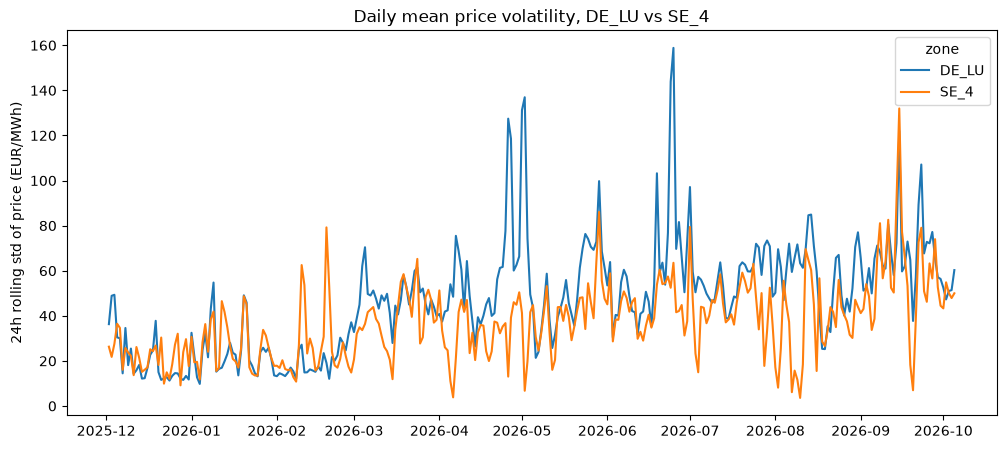

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

analysis_df["date"] = analysis_df["timestamp"].dt.date
daily_df = analysis_df.groupby(["zone", "date"])["volatility"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=daily_df, x="date", y="volatility", hue="zone", ax=ax)
ax.set_title("Daily mean price volatility, DE_LU vs SE_4")
ax.set_xlabel("")
ax.set_ylabel("24h rolling std of price (EUR/MWh)")
fig.savefig("../outputs/figures/volatility_daily.png", dpi=150, bbox_inches="tight")
plt.show()

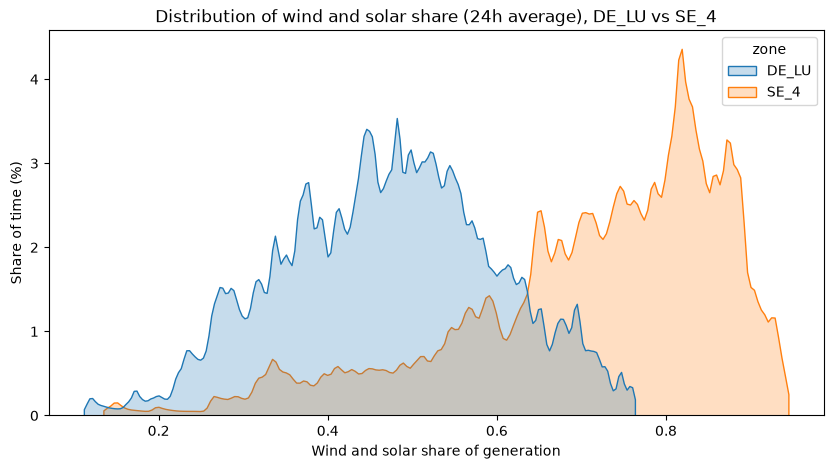

In [125]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    data=analysis_df,
    x="renewables_share_24h",
    hue="zone",
    common_norm=False,
    cut=0,
    bw_adjust=0.2,
    fill=True,
    ax=ax,
)
ax.set_title("Distribution of wind and solar share (24h average), DE_LU vs SE_4")
ax.set_xlabel("Wind and solar share of generation")
ax.set_ylabel("Share of time (%)")
fig.savefig("../outputs/figures/renewables_share_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

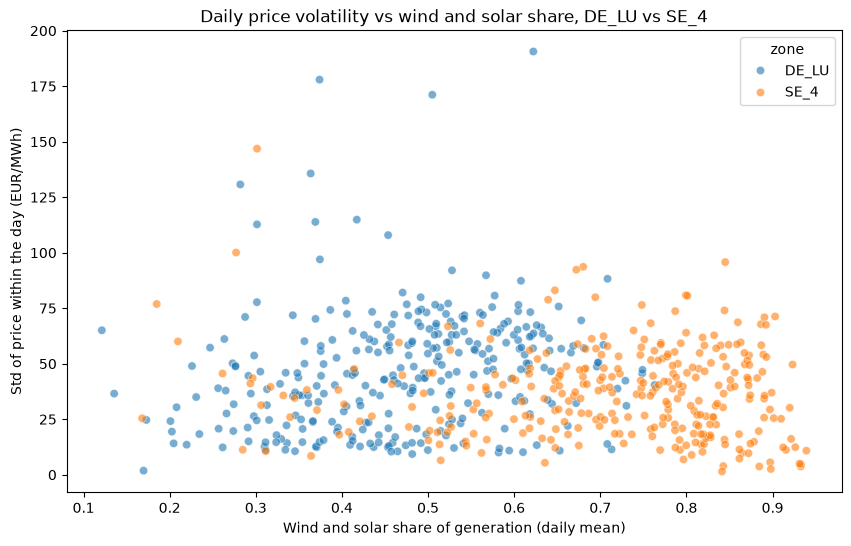

In [126]:
daily_points_df = (
    analysis_df.groupby(["zone", "date"])
    .agg(
        volatility=("price_eur_mwh", "std"),
        renewables_share=("renewables_share", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=daily_points_df, x="renewables_share", y="volatility", hue="zone", alpha=0.6, ax=ax
)
ax.set_title("Daily price volatility vs wind and solar share, DE_LU vs SE_4")
ax.set_xlabel("Wind and solar share of generation (daily mean)")
ax.set_ylabel("Std of price within the day (EUR/MWh)")
fig.savefig("../outputs/figures/volatility_vs_renewables_share.png", dpi=150, bbox_inches="tight")
plt.show()

Ok that doesnt look structured at all.... like no correlation, and maye even Skedacisity or however its spelled. Lets try something else.

<Axes: xlabel='renewables_share_24h', ylabel='volatility'>

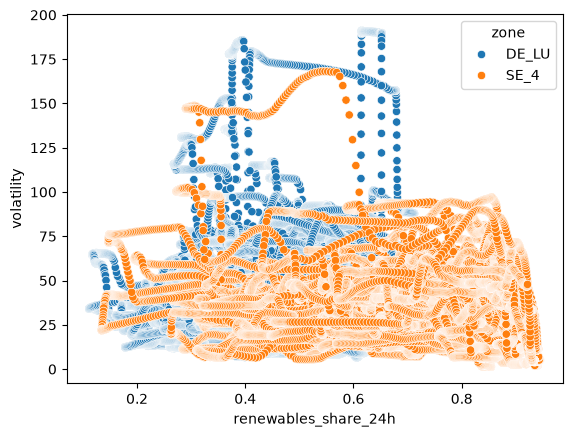

In [127]:
sns.scatterplot(data=analysis_df, x='renewables_share_24h', y='volatility', hue='zone')

Hmmm messy. And successive points share like 95% of datapoints feeding into the average from the rolling average, so of course we get trails. Never mind. Lets try something else.

In [129]:
gen2x=generation_wide_df.reset_index().copy()
gen2x['renewables_generation']=gen2x[['Wind Onshore','Wind Offshore','Solar']].sum(axis=1)
production_cols = generation_wide_df.columns.tolist()
gen2x['total_generation_mw']=gen2x[production_cols].sum(axis=1)
gen2x['wind_share'] = gen2x[['Wind Onshore', 'Wind Offshore']].sum(axis=1) / gen2x['total_generation_mw']
gen2x['solar_share'] = gen2x['Solar'] / gen2x['total_generation_mw']
gen2x['renewables_share']=gen2x['renewables_generation']/gen2x['total_generation_mw']
renewables_share_split_df=gen2x[["zone", "timestamp", "renewables_share", "wind_share", "solar_share"]].copy()
renewables_share_split_df["renewables_share_24h"] = (renewables_share_split_df.groupby("zone")["renewables_share"].rolling(96).mean().reset_index(level=0, drop=True))

analysis_split_df = df_price.merge(renewables_share_split_df, on=["zone", "timestamp"], validate="one_to_one")

ok we now split the shares and can look at them separately, mabe they have two different behaviours

In [132]:
analysis_split_df.isna().sum()
analysis_split_df.dropna(subset=["price_eur_mwh", "renewables_share", "renewables_share_24h", "volatility"], inplace=True)

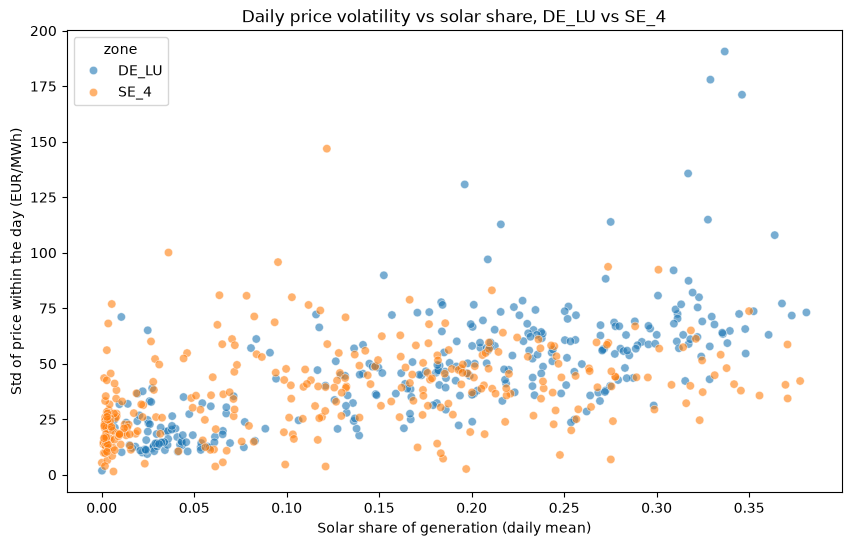

In [150]:
analysis_split_df["date"] = analysis_split_df["timestamp"].dt.date

daily_points_df = (
    analysis_split_df.groupby(["zone", "date"])
    .agg(
        volatility=("price_eur_mwh", "std"),
        renewables_share=("renewables_share", "mean"),
        wind_share=("wind_share", "mean"),
        solar_share=("solar_share", "mean"),
        price_max=("price_eur_mwh", "max"),
        price_min=("price_eur_mwh", "min"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=daily_points_df, x="solar_share", y="volatility", hue="zone", alpha=0.6, ax=ax
)
ax.set_title("Daily price volatility vs solar share, DE_LU vs SE_4")
ax.set_xlabel("Solar share of generation (daily mean)")
ax.set_ylabel("Std of price within the day (EUR/MWh)")
fig.savefig("../outputs/figures/volatility_vs_solar_share.png", dpi=150, bbox_inches="tight")
plt.show()

that actually looks vaguely correlated on the german side.

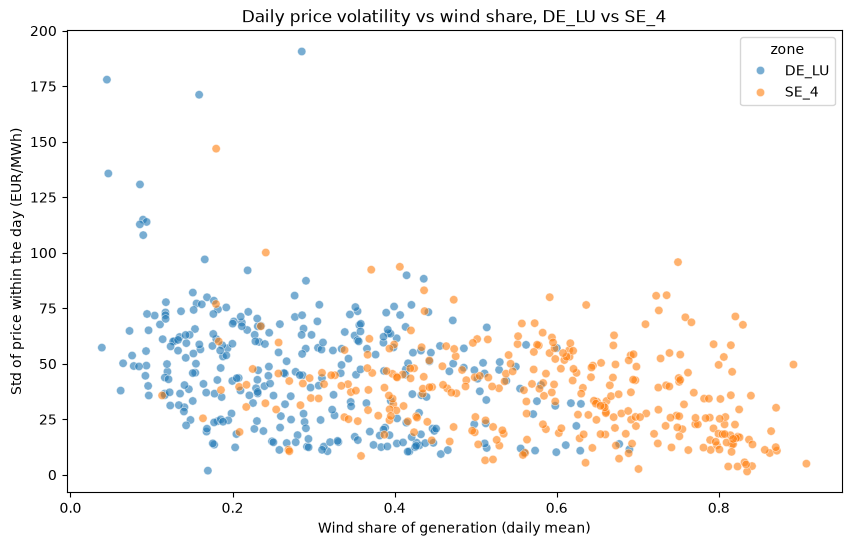

In [134]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=daily_points_df, x="wind_share", y="volatility", hue="zone", alpha=0.6, ax=ax
)
ax.set_title("Daily price volatility vs wind share, DE_LU vs SE_4")
ax.set_xlabel("Wind share of generation (daily mean)")
ax.set_ylabel("Std of price within the day (EUR/MWh)")
fig.savefig("../outputs/figures/volatility_vs_wind_share.png", dpi=150, bbox_inches="tight")
plt.show()

Ugh, yeah that doest look very correlated at all. But - we can check this.

In [135]:
daily_points_df.groupby("zone")[["volatility", "solar_share", "wind_share", "renewables_share"]].corr(method="spearman")

volatility  solar_share  wind_share  renewables_share
zone                                                                         
DE_LU volatility          1.000000     0.741873   -0.328882          0.261010
      solar_share         0.741873     1.000000   -0.511981          0.215379
      wind_share         -0.328882    -0.511981    1.000000          0.696194
      renewables_share    0.261010     0.215379    0.696194          1.000000
SE_4  volatility          1.000000     0.485103   -0.304460         -0.038984
      solar_share         0.485103     1.000000   -0.482433          0.059630
      wind_share         -0.304460    -0.482433    1.000000          0.813929
      renewables_share   -0.038984     0.059630    0.813929          1.000000

How to read this? Well, the numbers are the correlation (positive or negative) of the two variables scaled to [-1,1] where 1 would be perfect correlation (like the diagonal here). So solar is strongly correlated with volatility. Of course the two shares are negatively correlated - when solar is a very high share the relative importance of wind is lower.

We can now do a regression analysis as well:

In [137]:
for zone in ["DE_LU", "SE_4"]:
    zone_df = daily_points_df[daily_points_df["zone"] == zone]
    result = smf.ols("volatility ~ solar_share + wind_share", data=zone_df).fit(
        cov_type="HAC", cov_kwds={"maxlags": 7}
    )
    print(zone)
    print(result.summary())

DE_LU
                            OLS Regression Results                            
Dep. Variable:             volatility   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     77.34
Date:                Fri, 09 Oct 2026   Prob (F-statistic):           6.78e-28
Time:                        15:03:53   Log-Likelihood:                -1346.4
No. Observations:                 308   AIC:                             2699.
Df Residuals:                     305   BIC:                             2710.
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      13.8648      5.599      2.476

ok so look at the numbers for solar share - there we have a strong correlation, but for wind we really don't. Look at the p-values.

Lets check the zone difference a bit more carefully. Least square regression:

In [138]:
result = smf.ols("volatility ~ (solar_share + wind_share) * C(zone)", data=daily_points_df).fit(
    cov_type="HAC", cov_kwds={"maxlags": 7}
)
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:             volatility   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     40.82
Date:                Fri, 09 Oct 2026   Prob (F-statistic):           2.99e-36
Time:                        15:14:40   Log-Likelihood:                -2678.0
No. Observations:                 616   AIC:                             5368.
Df Residuals:                     610   BIC:                             5395.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

Ok wind is again not important but if we isolate the solar share we can graph the regression:

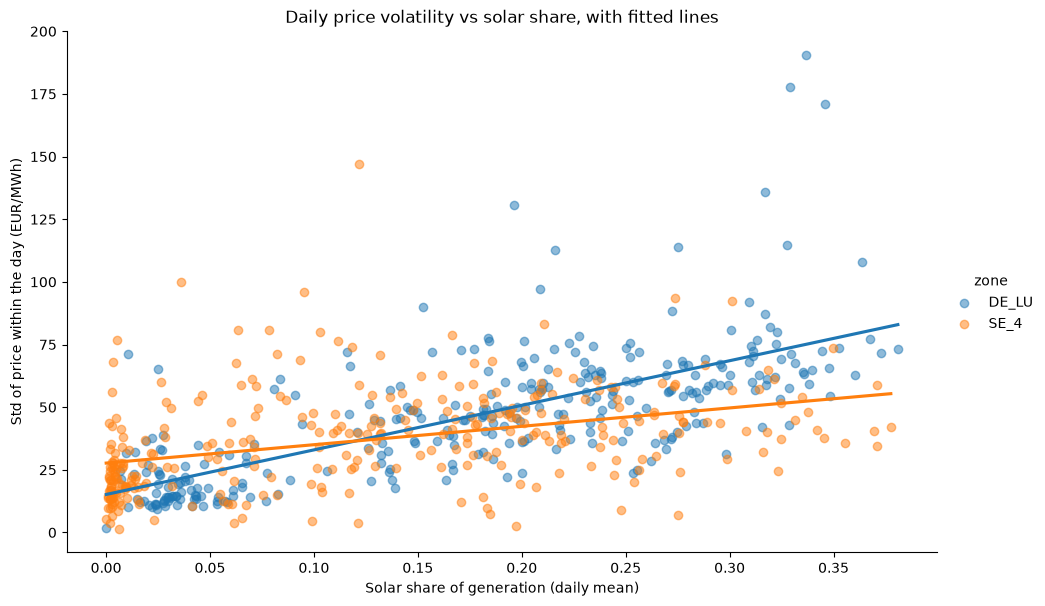

In [139]:
g = sns.lmplot(
    data=daily_points_df,
    x="solar_share",
    y="volatility",
    hue="zone",
    height=6,
    aspect=1.6,
    ci=None,
    scatter_kws={"alpha": 0.5},
)
g.set_axis_labels("Solar share of generation (daily mean)", "Std of price within the day (EUR/MWh)")
g.ax.set_title("Daily price volatility vs solar share, with fitted lines")
g.savefig("../outputs/figures/volatility_vs_solar_share_fit.png", dpi=150, bbox_inches="tight")
plt.show()

Seaborn also use OLS, so the line should be the same as in the table above.

Lets check for 

In [140]:
daily_points_df["month"] = pd.to_datetime(daily_points_df["date"]).dt.month

we can look at the effect of month on volatility, controlling for solar and wind share. This will help us understand if there are seasonal effects that are not captured by the renewable shares alone.

In [ ]:
for zone in ["DE_LU", "SE_4"]:
    zone_df = daily_points_df[daily_points_df["zone"] == zone]
    result = smf.ols("volatility ~ solar_share + wind_share + C(month)", data=zone_df).fit(
        cov_type="HAC", cov_kwds={"maxlags": 7}
    )
    print(zone)
    print(result.summary())

DE_LU
                            OLS Regression Results                            
Dep. Variable:             volatility   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     102.0
Date:                Fri, 09 Oct 2026   Prob (F-statistic):           2.44e-97
Time:                        15:21:07   Log-Likelihood:                -1323.0
No. Observations:                 308   AIC:                             2672.
Df Residuals:                     295   BIC:                             2721.
Df Model:                          12                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         13.0080      5.992  

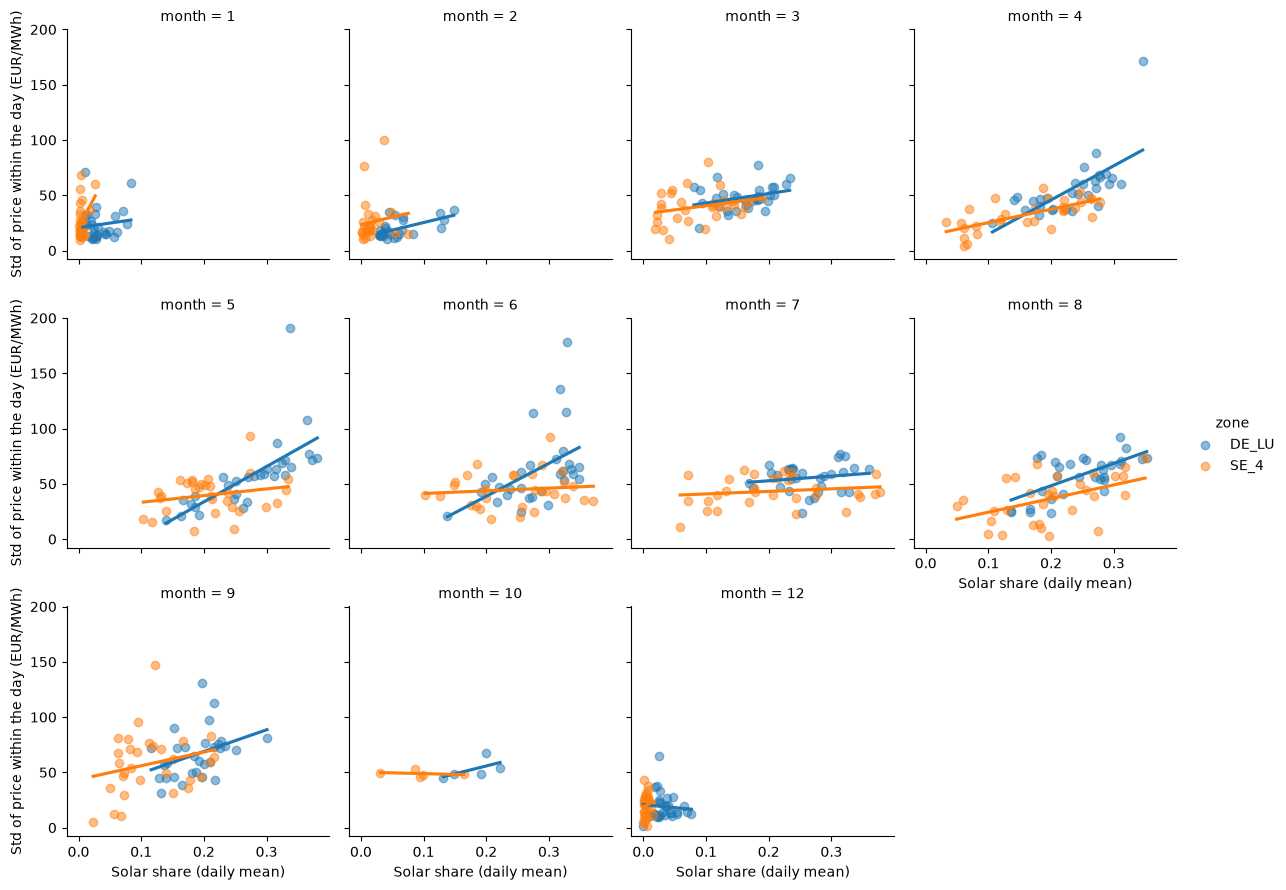

In [144]:
g = sns.lmplot(
    data=daily_points_df,
    x="solar_share",
    y="volatility",
    hue="zone",
    col="month",
    col_wrap=4,
    height=3,
    ci=None,
    scatter_kws={"alpha": 0.5},
)
g.set_axis_labels("Solar share (daily mean)", "Std of price within the day (EUR/MWh)")
g.savefig("../outputs/figures/volatility_vs_solar_share_by_month.png", dpi=150, bbox_inches="tight")
plt.show()

Above is a monthly graph.

In [143]:
import numpy as np

for zone in ["DE_LU", "SE_4"]:
    zone_df = daily_points_df[daily_points_df["zone"] == zone]
    result = smf.ols("np.log(volatility) ~ solar_share + wind_share", data=zone_df).fit(
        cov_type="HAC", cov_kwds={"maxlags": 7}
    )
    print(zone)
    print(result.summary())

DE_LU
                            OLS Regression Results                            
Dep. Variable:     np.log(volatility)   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.591
Method:                 Least Squares   F-statistic:                     127.7
Date:                Fri, 09 Oct 2026   Prob (F-statistic):           5.23e-41
Time:                        15:29:40   Log-Likelihood:                -162.56
No. Observations:                 308   AIC:                             331.1
Df Residuals:                     305   BIC:                             342.3
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.7228      0.119     22.856

The result holds when volatility is log-transformed, so it does not depend on a few extreme days.

In [151]:
daily_points_df["price_gap"] = daily_points_df["price_max"] - daily_points_df["price_min"]

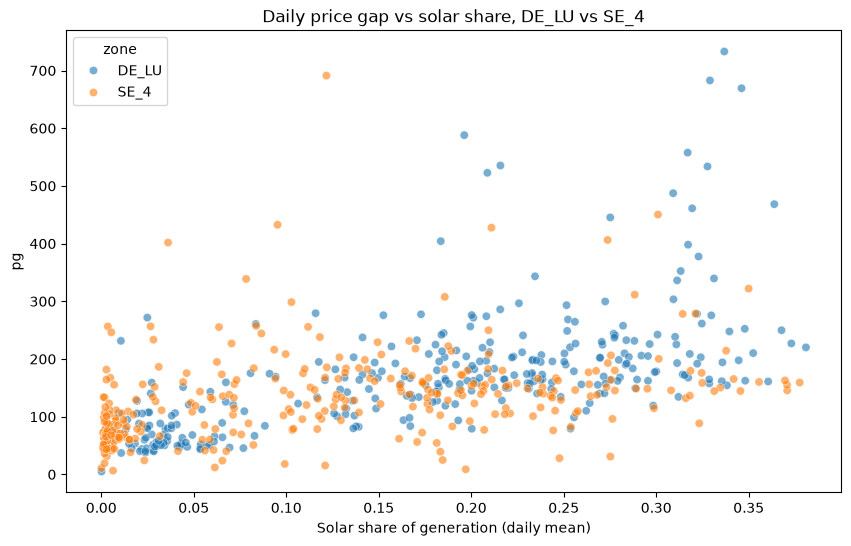

In [153]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=daily_points_df, x="solar_share", y="price_gap", hue="zone", alpha=0.6, ax=ax
)
ax.set_title("Daily price gap vs solar share, DE_LU vs SE_4")
ax.set_xlabel("Solar share of generation (daily mean)")
ax.set_ylabel("Daily max minus min price (EUR/MWh)")
fig.savefig("../outputs/figures/price_gap_vs_solar_share.png", dpi=150, bbox_inches="tight")
plt.show()

Look at that. Looks correlated.

Lets check pricing over a day.

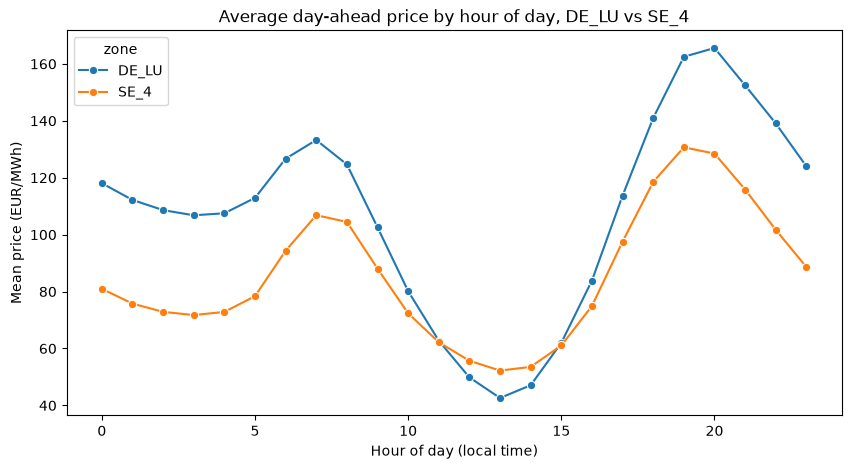

In [156]:
analysis_split_df["hour"] = analysis_split_df["timestamp"].dt.tz_convert("Europe/Berlin").dt.hour
hourly_df = analysis_split_df.groupby(["zone", "hour"])["price_eur_mwh"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=hourly_df, x="hour", y="price_eur_mwh", hue="zone", marker="o", ax=ax)
ax.set_title("Average day-ahead price by hour of day, DE_LU vs SE_4")
ax.set_xlabel("Hour of day (local time)")
ax.set_ylabel("Mean price (EUR/MWh)")
fig.savefig("../outputs/figures/price_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

Heh, lookit that, is that solar maximum maybe?